In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Input
import matplotlib.pyplot as plt
from pathlib import Path

2026-01-26 21:21:59.232193: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
BASE_DIR = Path.cwd().parent/ 'datasets'
BASE_DIR

PosixPath('/home/toqeer-yasir/Documents/repos/deep-learning/Deep_learning/datasets')

In [3]:
df = pd.read_csv(BASE_DIR/'Social_Network_Ads.csv')

In [4]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [9]:
X, y = df.iloc[:, :-1].values, df.iloc[:, -1].values

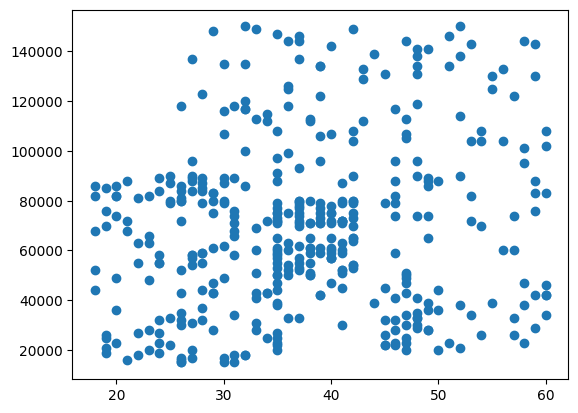

In [10]:
plt.scatter(x=X[:, 0], y=X[:, 1])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)

# training without scaling and results:

In [12]:
model = Sequential()

In [13]:
model.add(Input(shape=(2,)))
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [17]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3242 - loss: 3889.1123 - val_accuracy: 0.3281 - val_loss: 601.9769
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6211 - loss: 790.0526 - val_accuracy: 0.6719 - val_loss: 1114.5354
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6758 - loss: 572.8432 - val_accuracy: 0.3281 - val_loss: 324.0602
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3242 - loss: 464.3023 - val_accuracy: 0.6719 - val_loss: 195.6050
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6289 - loss: 196.8008 - val_accuracy: 0.3281 - val_loss: 140.2846
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5117 - loss: 149.3628 - val_accuracy: 0.6719 - val_loss: 57.4369
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5039 - loss: 114.5957 - val_accuracy: 0.6719 - val_loss: 199.1110
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5273 - loss: 93.1569 - va

In [18]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

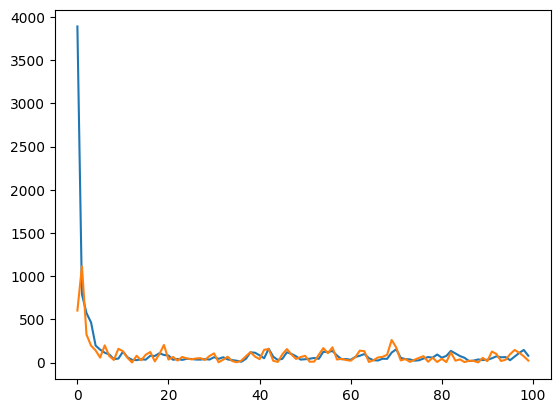

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

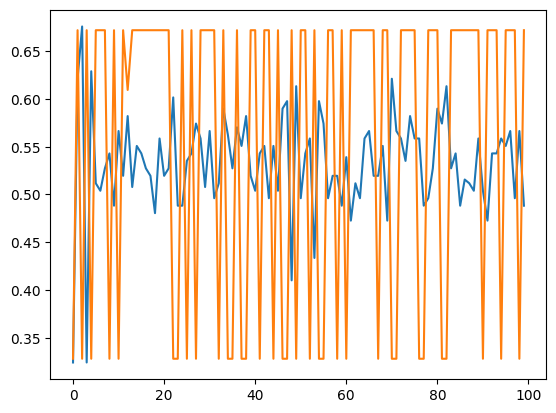

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

In [ ]:
# accuracy improvements with feature scaling(we do mean_centering if max and min value of data is known other wise we do normalizaton):

In [ ]:
scaler = StandardScaler()

In [26]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
X_train_scaled[:10]

array([[-1.06891459,  0.40607083],
       [-0.78187739, -0.74520483],
       [ 0.84466678,  0.19399374],
       [-0.01644484,  0.34547738],
       [ 0.74898771, -1.38143612],
       [-0.20780298,  0.22429046],
       [ 0.36627143, -0.13927027],
       [ 0.27059237,  0.22429046],
       [-0.20780298, -1.22995248],
       [-0.20780298,  0.13340028]])

In [28]:
model_with_scaled = Sequential()

In [29]:
model_with_scaled.add(Input(shape=(2,)))
model_with_scaled.add(Dense(256, activation='relu'))
model_with_scaled.add(Dense(1, activation='sigmoid'))

In [30]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [31]:
history_with_scaled = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=100)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6758 - loss: 0.6262 - val_accuracy: 0.6719 - val_loss: 0.6098
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6836 - loss: 0.5694 - val_accuracy: 0.7188 - val_loss: 0.5546
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7578 - loss: 0.5202 - val_accuracy: 0.7656 - val_loss: 0.5063
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7930 - loss: 0.4782 - val_accuracy: 0.8125 - val_loss: 0.4652
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8438 - loss: 0.4431 - val_accuracy: 0.8906 - val_loss: 0.4303
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8672 - loss: 0.4133 - val_accuracy: 0.8906 - val_loss: 0.4004
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8711 - loss: 0.3877 - val_accuracy: 0.8906 - val_loss: 0.3751
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8828 - loss: 0.3695 - val_accuracy: 0.9062 - val_loss:

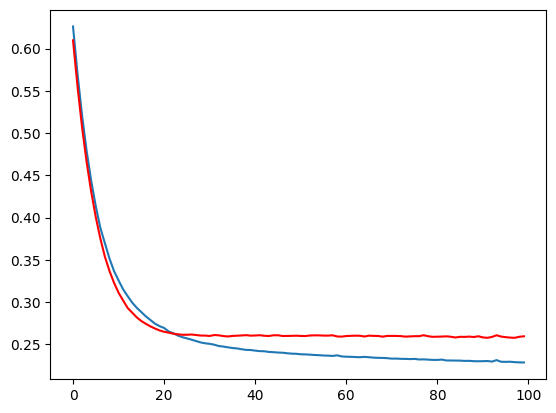

In [36]:
plt.plot(history_with_scaled.history['loss'])
plt.plot(history_with_scaled.history['val_loss'], color='red')
plt.show()

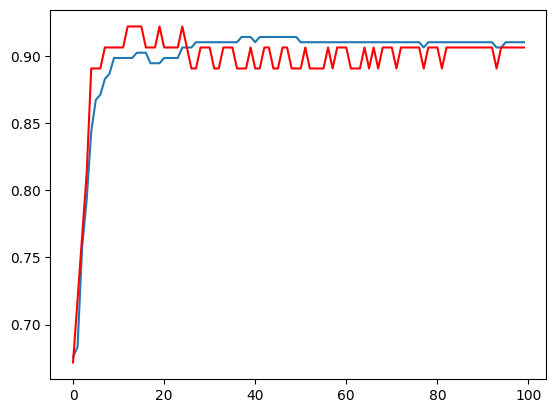

In [35]:
plt.plot(history_with_scaled.history['accuracy'])
plt.plot(history_with_scaled.history['val_accuracy'], color='red')
plt.show()